**Setup and Imports**

In [3]:

# !pip install tensorflow numpy scikit-learn matplotlib seaborn tifffile scikit-image opencv-python tqdm

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tifffile
import cv2
from skimage import exposure
import pickle
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version: 2.20.0
GPU available: False


**Configuration**

In [4]:
# ====================================================================

# ====================================================================

#  DATASET PATH
BASE_PATH = r'C:\Users\subas\PycharmProjects\JupyterProject\MG1655'  #

# Experiment settings
TARGET_CELLS_PER_CLASS = 500  # Total: 1000 cells
MAX_FILES_TO_PROCESS = 10     # first 10 files per condition
TARGET_SIZE = 64              # Image size (64x64 pixels)
BATCH_SIZE = 8
EPOCHS = 10

# Output directory
OUTPUT_DIR = Path('phase1_results')
OUTPUT_DIR.mkdir(exist_ok=True)

print(f" Configuration set")
print(f"   Dataset path: {BASE_PATH}")
print(f"   Target cells: {TARGET_CELLS_PER_CLASS * 2}")
print(f"   Output directory: {OUTPUT_DIR}")

 Configuration set
   Dataset path: C:\Users\subas\PycharmProjects\JupyterProject\MG1655
   Target cells: 1000
   Output directory: phase1_results


***Data** **Inspection***

In [5]:
class MinimalDataInspector:

    def __init__(self, base_path):
        self.base_path = Path(base_path)
        self.mg1655_path = self.base_path / r"C:\Users\subas\PycharmProjects\JupyterProject\MG1655"

    def inspect_one_file(self, condition='WT+ETOH'):


        img_folder = self.mg1655_path / "All_images" / condition
        mask_folder = self.mg1655_path / "All_segmentations" / condition

        # Get first file
        img_files = sorted(list(img_folder.glob('*.tif*')))

        if not img_files:
            print(f"No files found in {img_folder}")
            return None

        first_file = img_files[0]
        print(f" Inspecting: {first_file.name}")

        # Load
        img = tifffile.imread(str(first_file))
        mask_file = mask_folder / first_file.name

        if not mask_file.exists():
            print(f" Mask not found: {mask_file}")
            return None

        mask = tifffile.imread(str(mask_file))

        print(f"\n Image shape: {img.shape}")
        print(f"✓ Image dtype: {img.dtype}")
        print(f"✓ Image range: [{img.min()}, {img.max()}]")
        print(f"✓ Mask shape: {mask.shape}")
        print(f"✓ Mask dtype: {mask.dtype}")

        unique_vals = np.unique(mask)
        print(f" Unique mask values (first 10): {unique_vals[:10]}")
        print(f" Estimated cells in this image: {len(unique_vals) - 1}")

        return {
            'image_shape': img.shape,
            'mask_shape': mask.shape,
            'image_dtype': img.dtype,
            'mask_dtype': mask.dtype,
            'sample_image': img,
            'sample_mask': mask
        }

    def quick_test(self):

        print("="*70)
        print("CONDITION 1: UNTREATED (Resistant phenotype)")
        print("="*70)
        untreated = self.inspect_one_file('WT+ETOH')

        print("\n" + "="*70)
        print("CONDITION 2: CIPROFLOXACIN TREATED (Susceptible phenotype)")
        print("="*70)
        treated = self.inspect_one_file('CIP+ETOH')

        if untreated and treated:
            print("\n Both conditions found and inspected successfully!")


        return untreated, treated

print(" MinimalDataInspector class defined")

 MinimalDataInspector class defined


In [6]:
# Run inspection
inspector = MinimalDataInspector(BASE_PATH)
untreated_info, treated_info = inspector.quick_test()

#  inspection results
if untreated_info and treated_info:
    inspection_summary = {
        'untreated_shape': untreated_info['image_shape'],
        'treated_shape': treated_info['image_shape'],
        'mask_shape': untreated_info['mask_shape']
    }

    with open(OUTPUT_DIR / 'inspection_summary.txt', 'w') as f:
        f.write("DATASET INSPECTION SUMMARY\n")
        f.write("="*50 + "\n")
        f.write(f"Untreated image shape: {inspection_summary['untreated_shape']}\n")
        f.write(f"Treated image shape: {inspection_summary['treated_shape']}\n")
        f.write(f"Mask shape: {inspection_summary['mask_shape']}\n")

    print(f"\n Inspection summary saved to {OUTPUT_DIR / 'inspection_summary.txt'}")

CONDITION 1: UNTREATED (Resistant phenotype)
 Inspecting: 200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif


<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> shaped series metadata does not match page shape (684, 420, 3) != (3, 684, 420)
<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> invalid shaped series metadata or corrupted file



 Image shape: (684, 420, 3)
✓ Image dtype: uint16
✓ Image range: [0, 65535]
✓ Mask shape: (684, 420)
✓ Mask dtype: uint16
 Unique mask values (first 10): [0 1 2 3 4 5 6 7 8 9]
 Estimated cells in this image: 87

CONDITION 2: CIPROFLOXACIN TREATED (Susceptible phenotype)
 Inspecting: 200818_1_MG1655_NA_AMR_combined_1_CIP+ETOH_posXY0.tif

 Image shape: (3, 684, 420)
✓ Image dtype: uint16
✓ Image range: [0, 65535]
✓ Mask shape: (684, 420)
✓ Mask dtype: uint16
 Unique mask values (first 10): [0 1 2 3 4 5 6 7 8 9]
 Estimated cells in this image: 114

 Both conditions found and inspected successfully!

 Inspection summary saved to phase1_results\inspection_summary.txt


**Data Extraction**

In [7]:
class SmallDatasetExtractor:

    def __init__(self, base_path, target_cells_per_class=500):
        self.base_path = Path(base_path)
        self.mg1655_path = self.base_path
        self.target_cells = target_cells_per_class
        self.target_size = 64


    def parse_image(self, img):

        # Case 1: (3, H, W)
        if img.ndim == 3 and img.shape[0] == 3:
            dapi = img[0:1, :, :]       # Add frame dimension
            nile_red = img[1:2, :, :]
            return dapi, nile_red

        # Case 2: (H, W, 3)
        elif img.ndim == 3 and img.shape[2] == 3:
            dapi = img[:, :, 0][None, :, :]
            nile_red = img[:, :, 1][None, :, :]
            return dapi, nile_red

        else:
            raise ValueError(
                f" Unexpected image shape: {img.shape}"
            )

    def parse_mask(self, mask):

        if mask.ndim == 2:
            # Label map format
            cell_ids = np.unique(mask)
            cell_ids = cell_ids[cell_ids != 0]  # Remove background
            return [(mask == cid) for cid in cell_ids]

        elif mask.ndim == 3:
            # Already separated masks
            return [mask[:, :, i] for i in range(mask.shape[2])]

        else:
            raise ValueError(f"Unexpected mask shape: {mask.shape}")

    def extract_cell(self, dapi_stack, nile_red_stack, cell_mask):
        """Extract and preprocess one cell"""

        # Step 1: Average frames
        if dapi_stack.shape[0] > 1:
            dapi_avg = np.mean(dapi_stack, axis=0)
            nile_red_avg = np.mean(nile_red_stack, axis=0)
        else:
            dapi_avg = dapi_stack[0]
            nile_red_avg = nile_red_stack[0]

        # Step 2: Register DAPI to Nile Red using phase correlation
        try:
            shift, _ = cv2.phaseCorrelate(
                nile_red_avg.astype(np.float32),
                dapi_avg.astype(np.float32)
            )

            M = np.float32([[1, 0, shift[0]], [0, 1, shift[1]]])
            dapi_reg = cv2.warpAffine(
                dapi_avg, M,
                (dapi_avg.shape[1], dapi_avg.shape[0])
            )
        except:
            # If registration fails, use original
            dapi_reg = dapi_avg

        # Step 3: Crop to bounding box
        coords = np.argwhere(cell_mask)
        if len(coords) < 10:  # Skip tiny/invalid masks
            return None

        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)

        # Add small padding
        pad = 2
        y_min = max(0, y_min - pad)
        x_min = max(0, x_min - pad)
        y_max = min(dapi_reg.shape[0], y_max + pad)
        x_max = min(dapi_reg.shape[1], x_max + pad)

        dapi_crop = dapi_reg[y_min:y_max+1, x_min:x_max+1]
        nile_red_crop = nile_red_avg[y_min:y_max+1, x_min:x_max+1]
        mask_crop = cell_mask[y_min:y_max+1, x_min:x_max+1]

        # Step 4: Resize to target size (64×64)
        h, w = dapi_crop.shape

        if h < self.target_size or w < self.target_size:
            # Pad if too small
            pad_h = max(0, self.target_size - h)
            pad_w = max(0, self.target_size - w)

            dapi_crop = np.pad(dapi_crop, ((0, pad_h), (0, pad_w)), mode='constant')
            nile_red_crop = np.pad(nile_red_crop, ((0, pad_h), (0, pad_w)), mode='constant')
            mask_crop = np.pad(mask_crop, ((0, pad_h), (0, pad_w)), mode='constant')

        # Take center crop or resize
        dapi_resized = cv2.resize(
            dapi_crop[:self.target_size, :self.target_size],
            (self.target_size, self.target_size)
        ) if dapi_crop.shape[0] != self.target_size else dapi_crop[:self.target_size, :self.target_size]

        nile_red_resized = cv2.resize(
            nile_red_crop[:self.target_size, :self.target_size],
            (self.target_size, self.target_size)
        ) if nile_red_crop.shape[0] != self.target_size else nile_red_crop[:self.target_size, :self.target_size]

        mask_resized = cv2.resize(
            mask_crop[:self.target_size, :self.target_size].astype(np.uint8),
            (self.target_size, self.target_size),
            interpolation=cv2.INTER_NEAREST
        ).astype(bool) if mask_crop.shape[0] != self.target_size else mask_crop[:self.target_size, :self.target_size]

        # Step 5: Create RGB image (R=Nile Red, G=DAPI, B=0)
        rgb = np.zeros((self.target_size, self.target_size, 3), dtype=np.float32)
        rgb[:, :, 0] = nile_red_resized
        rgb[:, :, 1] = dapi_resized
        # Blue channel stays 0

        # Step 6: Histogram equalization within mask
        for ch in range(2):
            pixels = rgb[:, :, ch][mask_resized]
            if len(pixels) > 10:
                pmin, pmax = pixels.min(), pixels.max()
                if pmax > pmin:
                    norm = (pixels - pmin) / (pmax - pmin)
                    try:
                        equalized = exposure.equalize_hist(norm)
                        rgb[:, :, ch][mask_resized] = equalized
                    except:
                        # If equalization fails, just normalize
                        rgb[:, :, ch][mask_resized] = norm

        # Step 7: Convert to uint8
        rgb = np.clip(rgb * 255, 0, 255).astype(np.uint8)

        return rgb

    def extract_dataset(self, max_files=10):
        """Extract small dataset from limited files"""

        dataset = {
            'images': [],
            'labels': [],
            'metadata': []
        }

        # RESISTANT cells (untreated)
        print("="*70)
        print("Extracting RESISTANT cells (WT+ETOH)...")
        print("="*70)

        resistant_folder = self.mg1655_path / "All_images" / "WT+ETOH"
        resistant_masks = self.mg1655_path / "All_segmentations" / "WT+ETOH"

        img_files = sorted(list(resistant_folder.glob('*.tif*')))[:max_files]

        cells_extracted = 0
        for img_file in tqdm(img_files, desc="Processing files"):
            if cells_extracted >= self.target_cells:
                break

            try:
                # Load
                img = tifffile.imread(str(img_file))
                mask = tifffile.imread(str(resistant_masks / img_file.name))

                # Parse
                dapi, nile_red = self.parse_image(img)
                cell_masks = self.parse_mask(mask)

                # Extract cells
                for cell_mask in cell_masks:
                    if cells_extracted >= self.target_cells:
                        break

                    cell_img = self.extract_cell(dapi, nile_red, cell_mask)

                    if cell_img is not None:
                        dataset['images'].append(cell_img)
                        dataset['labels'].append(0)  # Resistant
                        dataset['metadata'].append({
                            'source_file': img_file.name,
                            'phenotype': 'resistant'
                        })
                        cells_extracted += 1

            except Exception as e:
                print(f"  Error processing {img_file.name}: {e}")
                continue

        print(f"Extracted {cells_extracted} resistant cells")

        # SUSCEPTIBLE cells (treated)
        print("\n" + "="*70)
        print("Extracting SUSCEPTIBLE cells (CIP+ETOH)...")
        print("="*70)

        susceptible_folder = self.mg1655_path / "All_images" / "CIP+ETOH"
        susceptible_masks = self.mg1655_path / "All_segmentations" / "CIP+ETOH"

        img_files = sorted(list(susceptible_folder.glob('*.tif*')))[:max_files]

        cells_extracted = 0
        for img_file in tqdm(img_files, desc="Processing files"):
            if cells_extracted >= self.target_cells:
                break

            try:
                img = tifffile.imread(str(img_file))
                mask = tifffile.imread(str(susceptible_masks / img_file.name))

                dapi, nile_red = self.parse_image(img)
                cell_masks = self.parse_mask(mask)

                for cell_mask in cell_masks:
                    if cells_extracted >= self.target_cells:
                        break

                    cell_img = self.extract_cell(dapi, nile_red, cell_mask)

                    if cell_img is not None:
                        dataset['images'].append(cell_img)
                        dataset['labels'].append(1)  # Susceptible
                        dataset['metadata'].append({
                            'source_file': img_file.name,
                            'phenotype': 'susceptible'
                        })
                        cells_extracted += 1

            except Exception as e:
                print(f"  Error processing {img_file.name}: {e}")
                continue

        print(f" Extracted {cells_extracted} susceptible cells")

        # Convert to arrays
        dataset['images'] = np.array(dataset['images'])
        dataset['labels'] = np.array(dataset['labels'])

        print("\n" + "="*70)
        print("DATASET EXTRACTION COMPLETE")
        print("="*70)
        print(f"Total images: {len(dataset['images'])}")
        print(f"Image shape: {dataset['images'].shape}")
        print(f"Resistant cells: {np.sum(dataset['labels']==0)}")
        print(f"Susceptible cells: {np.sum(dataset['labels']==1)}")

        return dataset

print(" SmallDatasetExtractor class defined")

 SmallDatasetExtractor class defined


In [8]:
# Extract dataset
extractor = SmallDatasetExtractor(
    BASE_PATH,
    target_cells_per_class=TARGET_CELLS_PER_CLASS
)

dataset = extractor.extract_dataset(max_files=MAX_FILES_TO_PROCESS)

# Save dataset
dataset_path = OUTPUT_DIR / 'small_dataset.npz'
np.savez_compressed(
    dataset_path,
    images=dataset['images'],
    labels=dataset['labels']
)

print(f"\n Dataset saved to {dataset_path}")
print(f"   File size: {dataset_path.stat().st_size / (1024**2):.1f} MB")

Extracting RESISTANT cells (WT+ETOH)...


Processing files:   0%|          | 0/10 [00:00<?, ?it/s]<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> shaped series metadata does not match page shape (684, 420, 3) != (3, 684, 420)
<tifffile.TiffFile '200818_1_MG1655_…ETOH_posXY0.tif'> invalid shaped series metadata or corrupted file
Processing files:  50%|█████     | 5/10 [00:12<00:12,  2.55s/it]


Extracted 500 resistant cells

Extracting SUSCEPTIBLE cells (CIP+ETOH)...


Processing files:  40%|████      | 4/10 [00:08<00:13,  2.17s/it]

 Extracted 500 susceptible cells

DATASET EXTRACTION COMPLETE
Total images: 1000
Image shape: (1000, 64, 64, 3)
Resistant cells: 500
Susceptible cells: 500

 Dataset saved to phase1_results\small_dataset.npz
   File size: 0.8 MB


**Visualization samples**

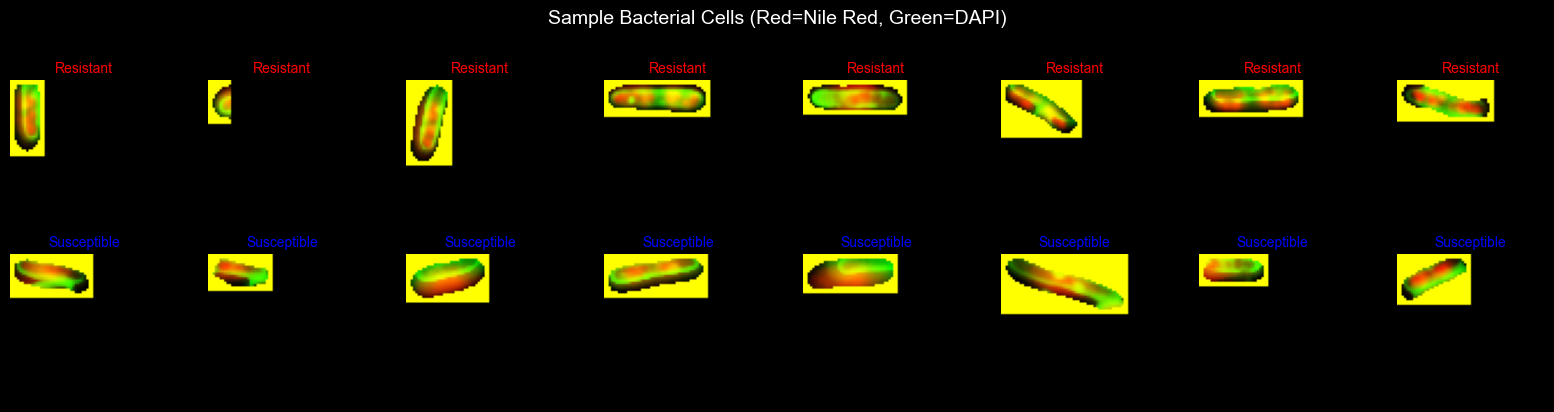

 Sample visualization saved to phase1_results\sample_cells.png


In [9]:
# Visualize random samples from each class
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

# Resistant cells
resistant_indices = np.where(dataset['labels'] == 0)[0]
sample_resistant = np.random.choice(resistant_indices, 8, replace=False)

for i, idx in enumerate(sample_resistant):
    axes[0, i].imshow(dataset['images'][idx])
    axes[0, i].set_title('Resistant', fontsize=10, color='red')
    axes[0, i].axis('off')

# Susceptible cells
susceptible_indices = np.where(dataset['labels'] == 1)[0]
sample_susceptible = np.random.choice(susceptible_indices, 8, replace=False)

for i, idx in enumerate(sample_susceptible):
    axes[1, i].imshow(dataset['images'][idx])
    axes[1, i].set_title('Susceptible', fontsize=10, color='blue')
    axes[1, i].axis('off')

plt.suptitle('Sample Bacterial Cells (Red=Nile Red, Green=DAPI)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sample_cells.png', dpi=150, bbox_inches='tight')
plt.show()

print(f" Sample visualization saved to {OUTPUT_DIR / 'sample_cells.png'}")

**Dataset Preparation**

In [10]:
# Load dataset
data = np.load(dataset_path)
X = data['images']
y = data['labels']

print(f"Dataset loaded: {X.shape}")
print(f"Labels: {y.shape}")
print(f"Class distribution: Resistant={np.sum(y==0)}, Susceptible={np.sum(y==1)}")

# Split data: 64% train, 16% val, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Normalize to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical
y_train_cat = tf.keras.utils.to_categorical(y_train, 2)
y_val_cat = tf.keras.utils.to_categorical(y_val, 2)
y_test_cat = tf.keras.utils.to_categorical(y_test, 2)

print(f"\n Data split complete:")
print(f"   Train: {X_train.shape[0]} samples")
print(f"   Val:   {X_val.shape[0]} samples")
print(f"   Test:  {X_test.shape[0]} samples")

Dataset loaded: (1000, 64, 64, 3)
Labels: (1000,)
Class distribution: Resistant=500, Susceptible=500

 Data split complete:
   Train: 640 samples
   Val:   160 samples
   Test:  200 samples


**CNN Model Building**

In [11]:
def build_lightweight_model(input_shape=(64, 64, 3), num_classes=2):
    """
 lightweight model using MobileNetV2
    """

    # Load pretrained base
    base = MobileNetV2(
        include_top=False,   #Dont include the final classification layer of MobileNet (DOG,CAT  10000 classes)
        weights='imagenet',
        input_shape=input_shape,
        alpha=1.0  # Width multiplier
    )

    # Freeze base initially
    base.trainable = False

    # Add custom head
    x = base.output
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dropout(0.3, name='dropout_1')(x)
    x = Dense(128, activation='relu', name='fc1')(x)
    x = Dropout(0.2, name='dropout_2')(x)
    outputs = Dense(num_classes, activation='softmax', name='predictions')(x)

    # Create model
    model = Model(inputs=base.input, outputs=outputs, name='BacteriaClassifier')

    return model

# Build model
model = build_lightweight_model()

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

# Summary
model.summary()

print(f"\n Model built and compiled")
print(f"   Total parameters: {model.count_params():,}")
print(f"   Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}")

Model: "BacteriaClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


 Model built and compiled
   Total parameters: 2,422,210
   Trainable parameters: 164,226


In [12]:
# Setup callbacks
callbacks = [
    ModelCheckpoint(
        filepath=OUTPUT_DIR / 'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

print(" Callbacks configured:")
print("   - Model checkpoint (saves best model)")
print("   - Early stopping (patience=5)")
print("   - Learning rate reduction (patience=3)")

 Callbacks configured:
   - Model checkpoint (saves best model)
   - Early stopping (patience=5)
   - Learning rate reduction (patience=3)


In [13]:
print("="*70)
print("STARTING TRAINING")
print("="*70)
print(f"Epochs: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Training samples: {len(X_train)}")
print("="*70)

# Train
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

#  final model
model.save(OUTPUT_DIR / 'final_model.h5')
print(f" Final model saved to {OUTPUT_DIR / 'final_model.h5'}")

#  training history
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print(f" Training history saved to {OUTPUT_DIR / 'training_history.csv'}")

STARTING TRAINING
Epochs: 10
Batch size: 8
Training samples: 640
Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6682 - loss: 0.7614 - precision: 0.6682 - recall: 0.6682
Epoch 1: val_accuracy improved from None to 0.78750, saving model to phase1_results\best_model.h5



Epoch 1: finished saving model to phase1_results\best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.7219 - loss: 0.6451 - precision: 0.7219 - recall: 0.7219 - val_accuracy: 0.7875 - val_loss: 0.5653 - val_precision: 0.7875 - val_recall: 0.7875 - learning_rate: 0.0010
Epoch 2/10
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8359 - loss: 0.4297 - precision: 0.8359 - recall: 0.8359
Epoch 2: val_accuracy improved from 0.78750 to 0.82500, saving model to phase1_results\best_model.h5



Epoch 2: finished saving model to phase1_results\best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8016 - loss: 0.4613 - precision: 0.8016 - recall: 0.8016 - val_accuracy: 0.8250 - val_loss: 0.4383 - val_precision: 0.8250 - val_recall: 0.8250 - learning_rate: 0.0010
Epoch 3/10
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8544 - loss: 0.3456 - precision: 0.8544 - recall: 0.8544
Epoch 3: val_accuracy did not improve from 0.82500
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8266 - loss: 0.3785 - precision: 0.8266 - recall: 0.8266 - val_accuracy: 0.8188 - val_loss: 0.4139 - val_precision: 0.8188 - val_recall: 0.8188 - learning_rate: 0.0010
Epoch 4/10
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8436 - loss: 0.3483 - precision: 0.8436 - recall: 0.8436
Epoch 4: val_accuracy did not improve from 0.82500
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.8438 - loss: 0.3698 - precision: 0.8438 - recall: 0.8438 - val_accuracy: 0.7250 - val_loss: 


Epoch 5: finished saving model to phase1_results\best_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8734 - loss: 0.3156 - precision: 0.8734 - recall: 0.8734 - val_accuracy: 0.8313 - val_loss: 0.4395 - val_precision: 0.8313 - val_recall: 0.8313 - learning_rate: 0.0010
Epoch 6/10
78/80 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8663 - loss: 0.3156 - precision: 0.8663 - recall: 0.8663
Epoch 6: val_accuracy did not improve from 0.83125

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8656 - loss: 0.3150 - precision: 0.8656 - recall: 0.8656 - val_accuracy: 0.8188 - val_loss: 0.4306 - val_precision: 0.8188 - val_recall: 0.8188 - learning_rate: 0.0010
Epoch 7/10
79/80 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8966 - loss: 0.2738 - precision: 0.8966 - recall: 0.8966
Epoch 7: val_accuracy did not improve from 0.83125
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8781 - loss: 0.


 Training complete!
 Final model saved to phase1_results\final_model.h5
 Training history saved to phase1_results\training_history.csv


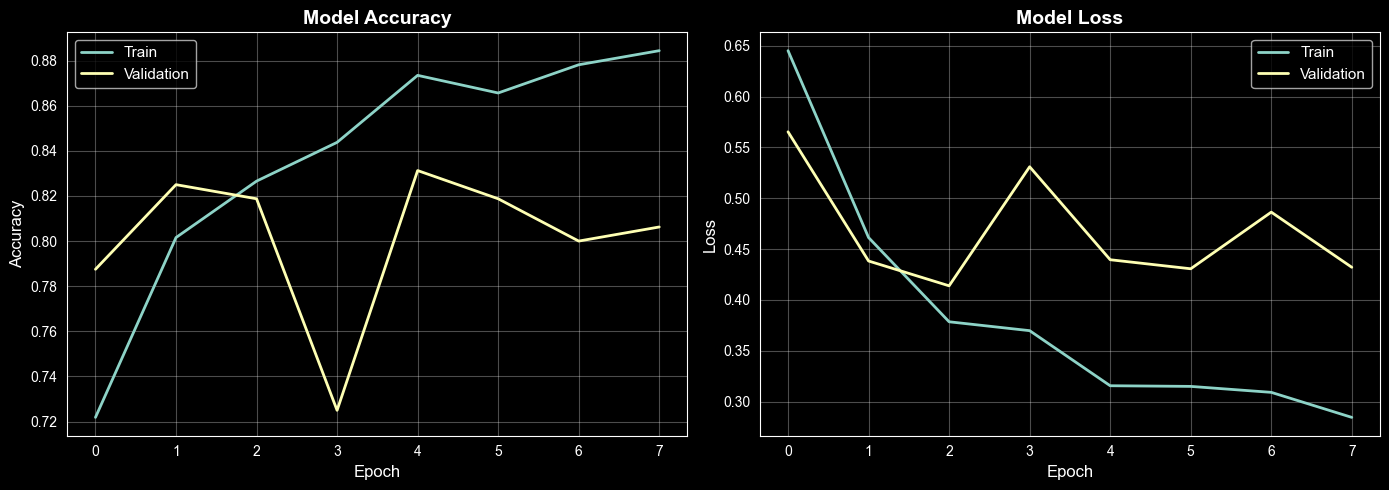

 Training curves saved to phase1_results\training_curves.png

 Best Validation Accuracy: 0.8313 (Epoch 5)


In [14]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Training curves saved to {OUTPUT_DIR / 'training_curves.png'}")

# Print best metrics
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"\n Best Validation Accuracy: {history.history['val_accuracy'][best_epoch]:.4f} (Epoch {best_epoch+1})")

In [15]:
print("="*70)
print("*" *70)
print("EVALUATING ON TEST SET")
print("="*70)
print("*" *70)

# Load best model
best_model = tf.keras.models.load_model(OUTPUT_DIR / 'best_model.h5')

# Evaluate
test_results = best_model.evaluate(X_test, y_test_cat, verbose=1)

print(f"\nTest Results:")
print(f"   Loss: {test_results[0]:.4f}")
print(f"   Accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)")
print(f"   Precision: {test_results[2]:.4f}")
print(f"   Recall: {test_results[3]:.4f}")

# Predict
y_pred_probs = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Save predictions
np.savez(
    OUTPUT_DIR / 'test_predictions.npz',
    y_true=y_test,
    y_pred=y_pred,
    y_pred_probs=y_pred_probs
)

print(f" Predictions saved to {OUTPUT_DIR / 'test_predictions.npz'}")

**********************************************************************
EVALUATING ON TEST SET
**********************************************************************


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.7700 - loss: 0.5364 - precision: 0.7700 - recall: 0.7700

Test Results:
   Loss: 0.5364
   Accuracy: 0.7700 (77.00%)
   Precision: 0.7700
   Recall: 0.7700
 Predictions saved to phase1_results\test_predictions.npz


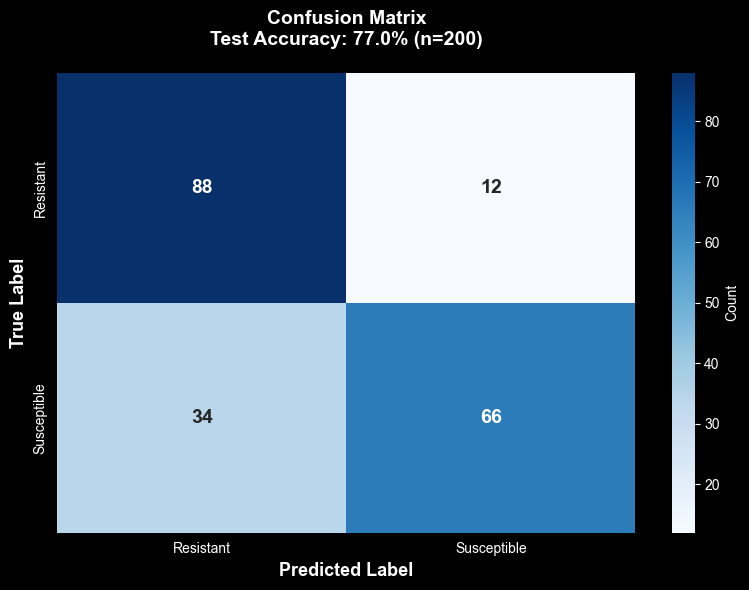

 Confusion matrix saved to phase1_results\confusion_matrix.png

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Resistant     0.7213    0.8800    0.7928       100
 Susceptible     0.8462    0.6600    0.7416       100

    accuracy                         0.7700       200
   macro avg     0.7837    0.7700    0.7672       200
weighted avg     0.7837    0.7700    0.7672       200



In [16]:
#  confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Resistant', 'Susceptible'],
    yticklabels=['Resistant', 'Susceptible'],
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 14, 'weight': 'bold'}
)

plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix\nTest Accuracy: {test_results[1]*100:.1f}% (n={len(y_test)})',
          fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Confusion matrix saved to {OUTPUT_DIR / 'confusion_matrix.png'}")

# detailed classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(
    y_test, y_pred,
    target_names=['Resistant', 'Susceptible'],
    digits=4
))

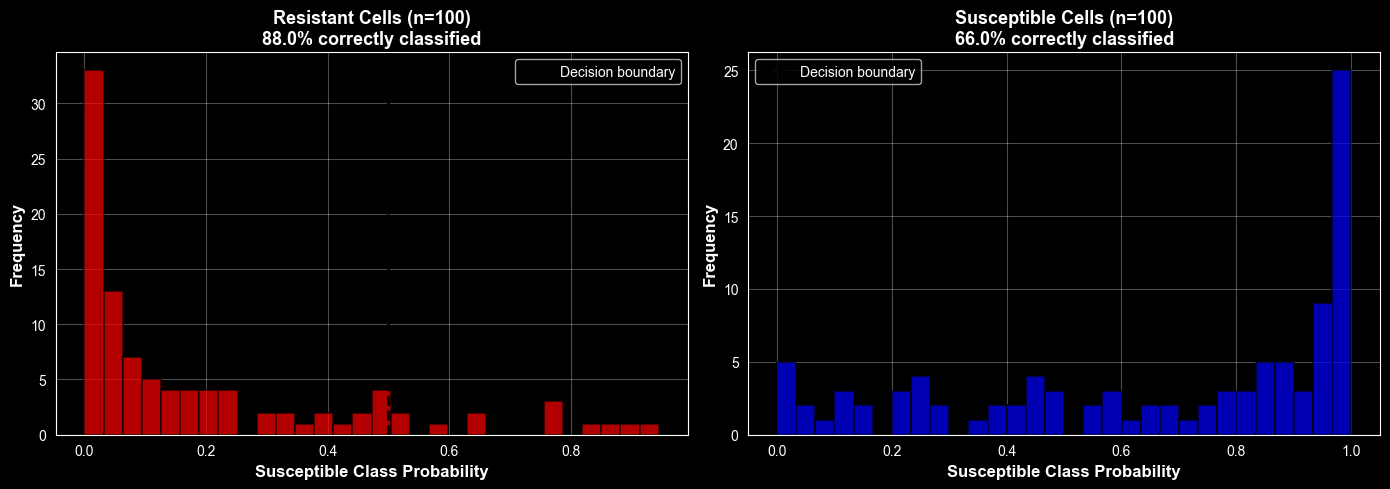

 Confidence distribution saved to phase1_results\confidence_distribution.png


In [17]:
# Confidence distributions (like paper Figure 4)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get probabilities for susceptible class
resistant_probs = y_pred_probs[y_test == 0, 1]
susceptible_probs = y_pred_probs[y_test == 1, 1]

# Plot resistant cells
axes[0].hist(resistant_probs, bins=30, alpha=0.7, color='red', edgecolor='black', linewidth=1.2)
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
axes[0].set_xlabel('Susceptible Class Probability', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].set_title(f'Resistant Cells (n={len(resistant_probs)})\n'
                  f'{np.sum(resistant_probs < 0.5)/len(resistant_probs)*100:.1f}% correctly classified',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot susceptible cells
axes[1].hist(susceptible_probs, bins=30, alpha=0.7, color='blue', edgecolor='black', linewidth=1.2)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision boundary')
axes[1].set_xlabel('Susceptible Class Probability', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title(f'Susceptible Cells (n={len(susceptible_probs)})\n'
                  f'{np.sum(susceptible_probs >= 0.5)/len(susceptible_probs)*100:.1f}% correctly classified',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confidence_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Confidence distribution saved to {OUTPUT_DIR / 'confidence_distribution.png'}")

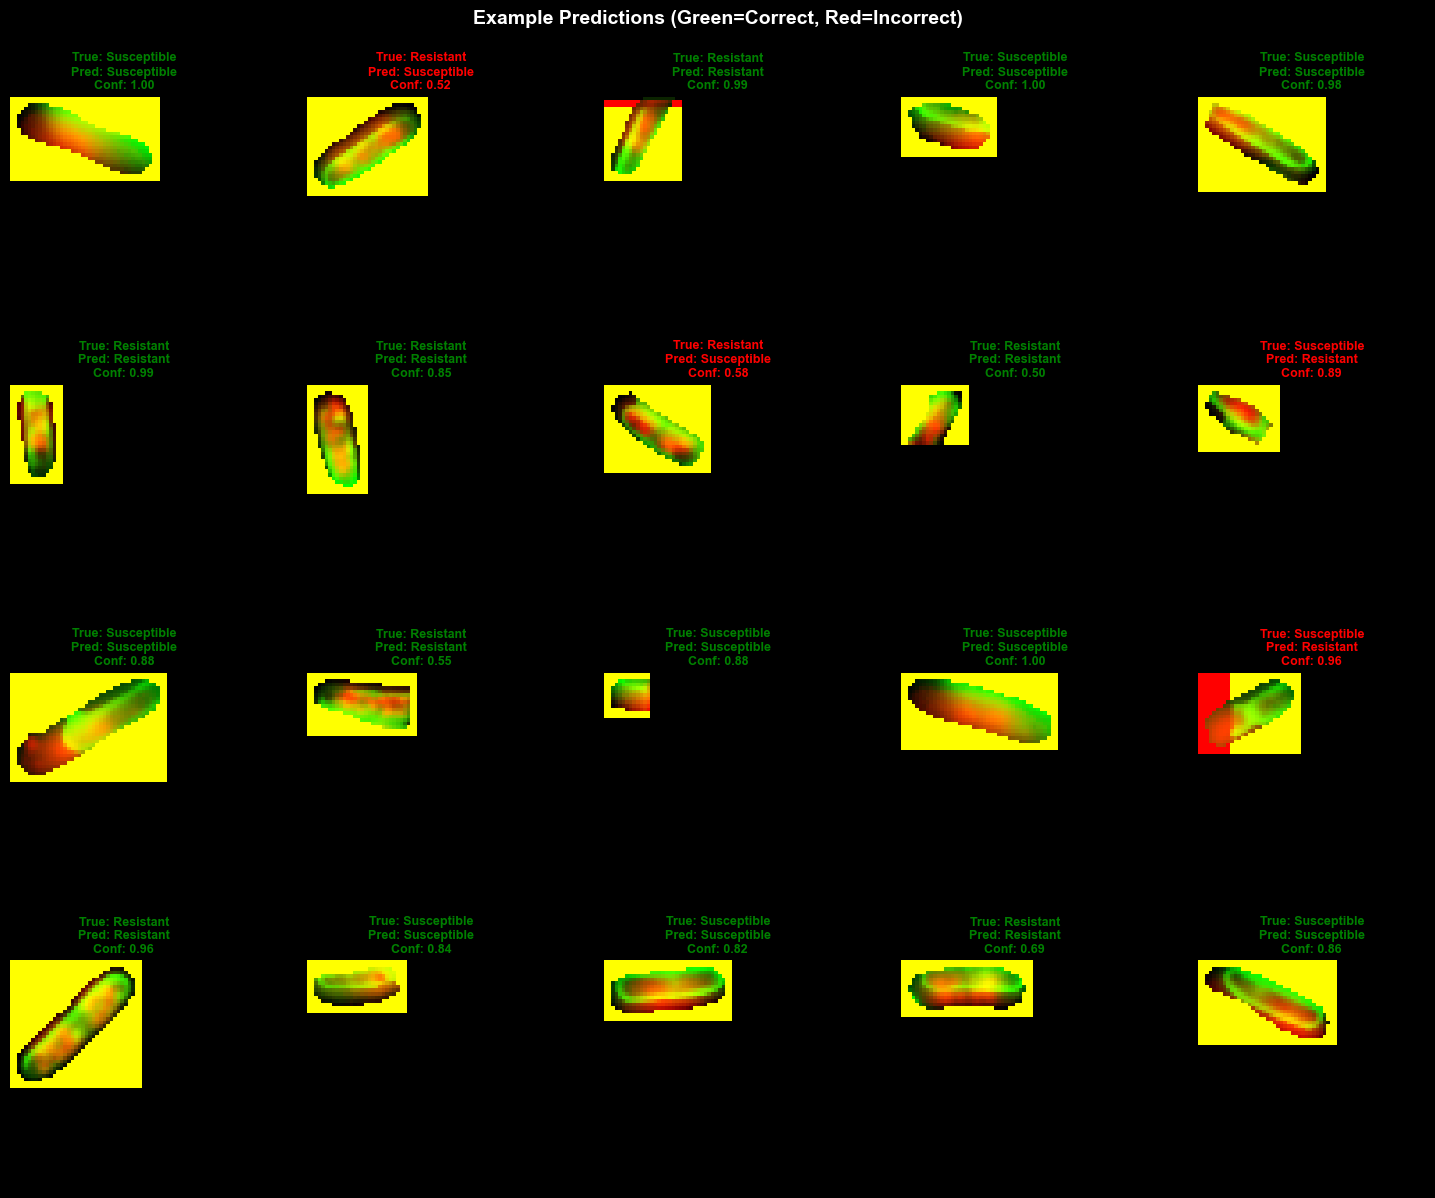

 Example predictions saved to phase1_results\example_predictions.png


In [18]:
#  example predictions
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
axes = axes.ravel()

# S 20 random test images
indices = np.random.choice(len(X_test), 20, replace=False)

for i, idx in enumerate(indices):
    # Display image
    axes[i].imshow(X_test[idx])

    # Get labels and predictions
    true_label = 'Resistant' if y_test[idx] == 0 else 'Susceptible'
    pred_label = 'Resistant' if y_pred[idx] == 0 else 'Susceptible'
    confidence = y_pred_probs[idx, y_pred[idx]]

    # Color: green if correct, red if wrong
    color = 'green' if y_test[idx] == y_pred[idx] else 'red'

    axes[i].set_title(
        f'True: {true_label}\n'
        f'Pred: {pred_label}\n'
        f'Conf: {confidence:.2f}',
        fontsize=9,
        color=color,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle('Example Predictions (Green=Correct, Red=Incorrect)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'example_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f" Example predictions saved to {OUTPUT_DIR / 'example_predictions.png'}")

In [19]:
# Generate text report
report = f"""
{'='*70}
BACTERIAL AST CLASSIFICATION - PHASE 1 RESULTS
{'='*70}

DATASET INFORMATION
-------------------
Total cells extracted: {len(dataset['labels'])}
Resistant cells: {np.sum(dataset['labels']==0)}
Susceptible cells: {np.sum(dataset['labels']==1)}

DATA SPLIT
----------
Training samples: {len(X_train)}
Validation samples: {len(X_val)}
Test samples: {len(X_test)}

MODEL ARCHITECTURE
------------------
Base: MobileNetV2 (pretrained on ImageNet)
Input shape: (64, 64, 3)
Total parameters: {model.count_params():,}
Trainable parameters: {sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]):,}

TRAINING CONFIGURATION
----------------------
Epochs: {EPOCHS}
Batch size: {BATCH_SIZE}
Optimizer: Adam
Initial learning rate: 0.001
Loss function: Categorical crossentropy

BEST RESULTS
------------
Best validation accuracy: {history.history['val_accuracy'][best_epoch]:.4f} (Epoch {best_epoch+1})
Test accuracy: {test_results[1]:.4f} ({test_results[1]*100:.2f}%)
Test precision: {test_results[2]:.4f}
Test recall: {test_results[3]:.4f}

CONFUSION MATRIX
----------------
                    Predicted
                Resistant  Susceptible
Actual Resistant      {cm[0,0]}         {cm[0,1]}
       Susceptible    {cm[1,0]}         {cm[1,1]}


FILES GENERATED
---------------------------
- small_dataset.npz (processed cells)
- best_model.h5 (trained model)
- final_model.h5 (final model)
- training_history.csv (training metrics)
- sample_cells.png (example cells)
- training_curves.png (training progress)
- confusion_matrix.png (performance)
- confidence_distribution.png (predictions)
- example_predictions.png (visual examples)
- phase1_report.txt (this report)

{'='*70}
{'='*70}
"""

# report
with open(OUTPUT_DIR / 'phase1_report.txt', 'w') as f:
    f.write(report)

print(report)
print(f"\n Full report saved to {OUTPUT_DIR / 'phase1_report.txt'}")


BACTERIAL AST CLASSIFICATION - PHASE 1 RESULTS

DATASET INFORMATION
-------------------
Total cells extracted: 1000
Resistant cells: 500
Susceptible cells: 500

DATA SPLIT
----------
Training samples: 640
Validation samples: 160
Test samples: 200

MODEL ARCHITECTURE
------------------
Base: MobileNetV2 (pretrained on ImageNet)
Input shape: (64, 64, 3)
Total parameters: 2,422,210
Trainable parameters: 164,226

TRAINING CONFIGURATION
----------------------
Epochs: 10
Batch size: 8
Optimizer: Adam
Initial learning rate: 0.001
Loss function: Categorical crossentropy

BEST RESULTS
------------
Best validation accuracy: 0.8313 (Epoch 5)
Test accuracy: 0.7700 (77.00%)
Test precision: 0.7700
Test recall: 0.7700

CONFUSION MATRIX
----------------
                    Predicted
                Resistant  Susceptible
Actual Resistant      88         12
       Susceptible    34         66


FILES GENERATED
---------------------------
- small_dataset.npz (processed cells)
- best_model.h5 (trained m